In [1]:
# Imports and load the files

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
pokemon = pd.read_csv("Pokemon Data Analysis Tutorial/pokemon.csv")
combats = pd.read_csv("Pokemon Data Analysis Tutorial/combats.csv")

In [3]:
pokemon.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [4]:
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [6]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [7]:
combats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


In [8]:
# check missing values
pokemon.isna().sum()

#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [9]:
# Fill missing Name for Primeape.
# In this actual CSV file, the missing name is for Pokemon #63, not #62.
pokemon.loc[pokemon["#"] == 63, "Name"] = "Primeape"

# Fill missing Type 2 values
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

In [10]:
pokemon.isna().sum()

#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

In [11]:
# Calculate each Pokémon’s win percentage

# Count how many times each Pokemon appears as First_pokemon
first_counts = combats["First_pokemon"].value_counts()

# Count how many times each Pokemon appears as Second_pokemon
second_counts = combats["Second_pokemon"].value_counts()

# Total battles = battles as first + battles as second
total_battles = first_counts.add(second_counts, fill_value=0)

# Count how many times each Pokemon appears in the Winner column
wins = combats["Winner"].value_counts()

# Win percentage = wins / total battles
win_percentage = wins.divide(total_battles, fill_value=0)

In [12]:
win_df = pd.DataFrame({
    "Total_Battles": total_battles,
    "Wins": wins,
    "Win_Percentage": win_percentage
})

win_df.head()

,Total_Battles,Wins,Win_Percentage
1,133,37.0,0.278195
2,121,46.0,0.380165
3,132,89.0,0.674242
4,125,70.0,0.560000
5,112,55.0,0.491071


In [13]:
win_df = win_df.fillna(0)

In [14]:
win_df = win_df.reset_index()
win_df = win_df.rename(columns={"index": "#"})

In [15]:
pokemon_merged = pokemon.merge(win_df, on="#", how="left")

In [16]:
pokemon_merged[["Total_Battles", "Wins", "Win_Percentage"]] = pokemon_merged[
    ["Total_Battles", "Wins", "Win_Percentage"]
].fillna(0)

In [17]:
pokemon_merged.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total_Battles,Wins,Win_Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,0.278195
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,0.380165
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,0.674242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,0.560000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,0.491071


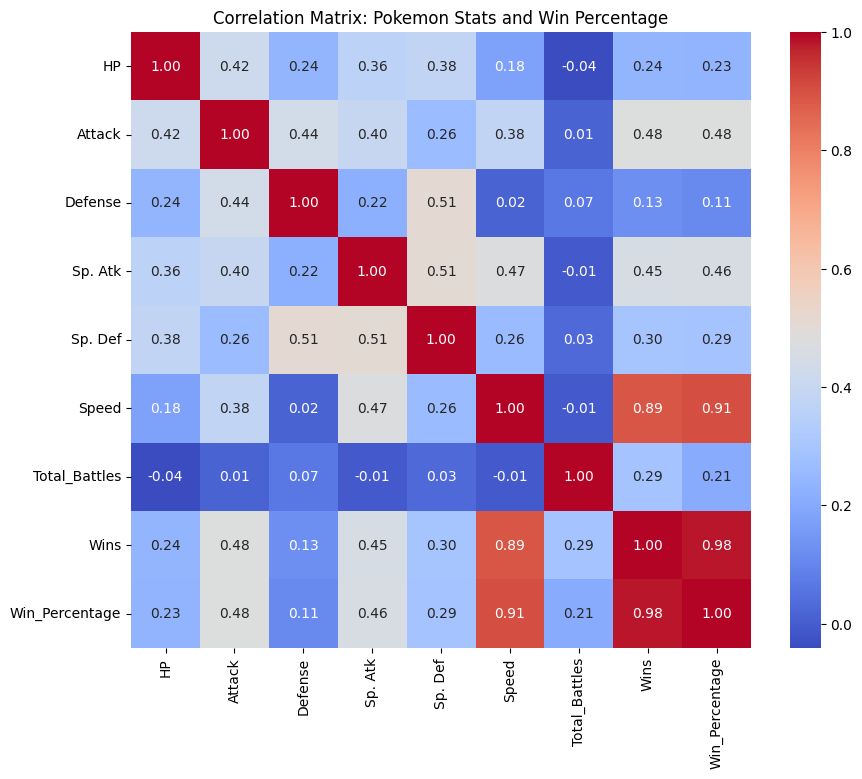

In [18]:
# Correlation matrix

numeric_cols = [
    "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed",
    "Total_Battles", "Wins", "Win_Percentage"
]

corr_matrix = pokemon_merged[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix: Pokemon Stats and Win Percentage")
plt.show()

**Observation**: The correlation matrix shows that Speed has the strongest positive relationship with Win_Percentage, with a correlation of 0.91. This suggests that faster Pokémon tend to win much more often in this dataset. Attack and Sp. Atk also have moderate positive correlations with Win_Percentage, at 0.48 and 0.46 respectively, indicating that offensive power also contributes to battle success.

Defensive stats are less strongly related to winning. Defense has a very weak correlation with Win_Percentage, only 0.11, while Sp. Def has a weak-to-moderate correlation of 0.29. HP also has only a weak positive correlation of 0.23.

The very high correlation between Wins and Win_Percentage, 0.98, is expected because Win_Percentage is calculated directly from wins divided by total battles. Therefore, Wins should not be used as a feature in the machine learning models, since it would create data leakage.

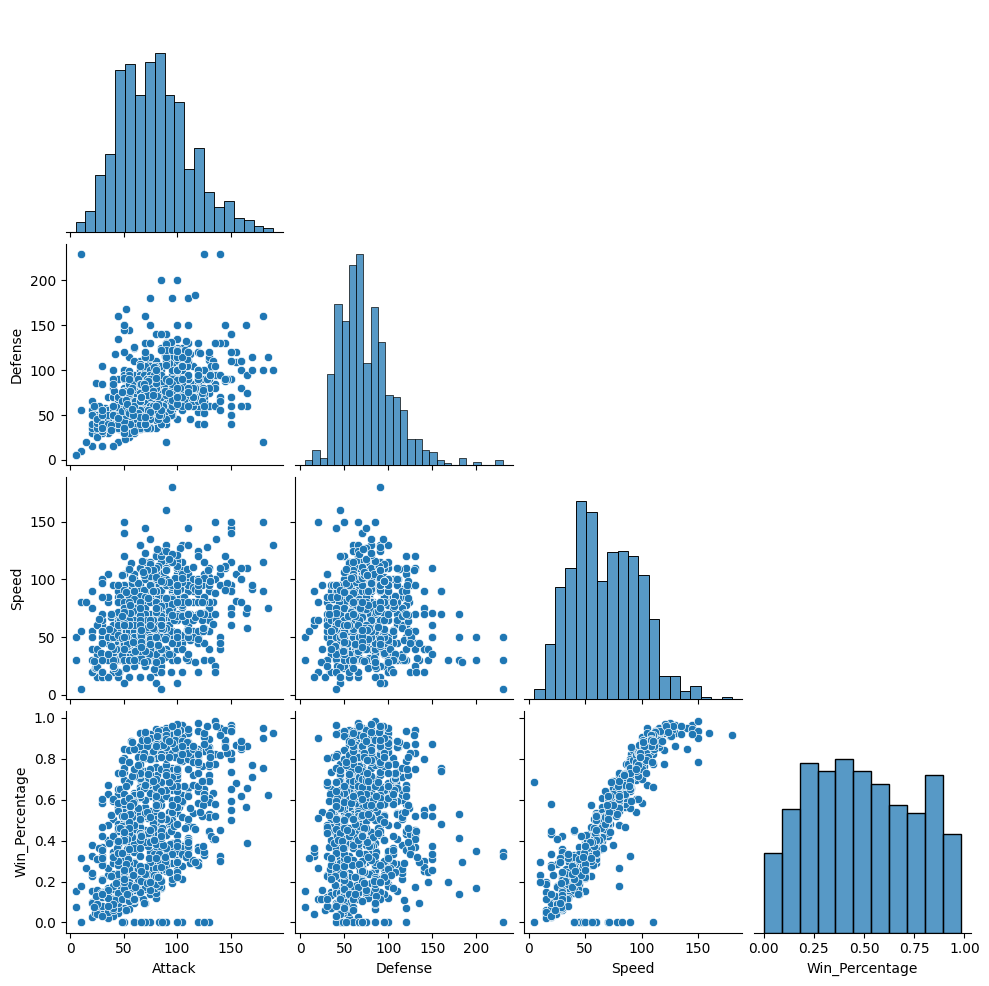

In [20]:
sns.pairplot(
    pokemon_merged[["Attack", "Defense", "Speed", "Win_Percentage"]],
    corner=True
)

plt.show()

**Observation**: The pairplot confirms the relationships observed in the correlation matrix. The clearest pattern is between Speed and Win_Percentage. The scatterplot shows a strong positive relationship: as Speed increases, Win_Percentage also tends to increase. This supports the correlation result, where Speed had the strongest association with winning.

Attack also shows a positive relationship with Win_Percentage, but the pattern is weaker and more scattered. This suggests that offensive strength helps, but high Attack alone does not guarantee a high win percentage.

Defense shows the weakest relationship with Win_Percentage. The points are widely scattered, and there is no clear upward trend. This suggests that Defense is not a strong predictor of battle success in this dataset.

Overall, the pairplot visually supports the conclusion that Speed is the most important individual stat among the selected variables for predicting win percentage.

In [24]:
# Top 10 Pokémon by win percentage

top_10 = pokemon_merged.sort_values("Win_Percentage", ascending=False).head(10)

top_10[
    ["#", "Name", "Type 1", "Type 2", "HP", "Attack", "Defense",
     "Sp. Atk", "Sp. Def", "Speed", "Legendary", "Total_Battles",
     "Wins", "Win_Percentage"]
]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,Total_Battles,Wins,Win_Percentage
154,155,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,False,129.0,127.0,0.984496
512,513,Weavile,Dark,Ice,70,120,65,45,85,125,False,119.0,116.0,0.974790
703,704,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,True,125.0,121.0,0.968000
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,False,119.0,115.0,0.966387
153,154,Aerodactyl,Rock,Flying,80,105,65,60,75,130,False,141.0,136.0,0.964539
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,False,129.0,124.0,0.961240
726,727,Greninja,Water,Dark,72,95,67,103,71,122,False,127.0,122.0,0.960630
716,717,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,False,123.0,118.0,0.959350
164,165,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,True,125.0,119.0,0.952000
349,350,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,False,120.0,114.0,0.950000


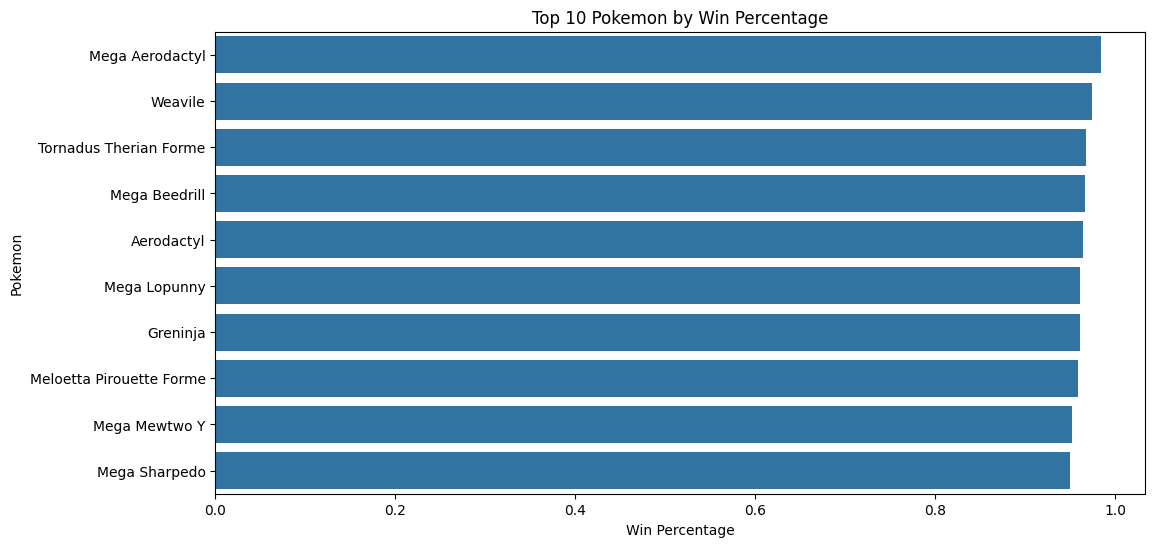

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x="Win_Percentage", y="Name")
plt.title("Top 10 Pokemon by Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Pokemon")
plt.show()

In [26]:
top_10_stats = top_10[
    ["Name", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
]

top_10_stats

,Name,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
154,Mega Aerodactyl,80,135,85,70,95,150
512,Weavile,70,120,65,45,85,125
703,Tornadus Therian Forme,79,100,80,110,90,121
19,Mega Beedrill,65,150,40,15,80,145
153,Aerodactyl,80,105,65,60,75,130
476,Mega Lopunny,65,136,94,54,96,135
726,Greninja,72,95,67,103,71,122
716,Meloetta Pirouette Forme,100,128,90,77,77,128
164,Mega Mewtwo Y,106,150,70,194,120,140
349,Mega Sharpedo,70,140,70,110,65,105


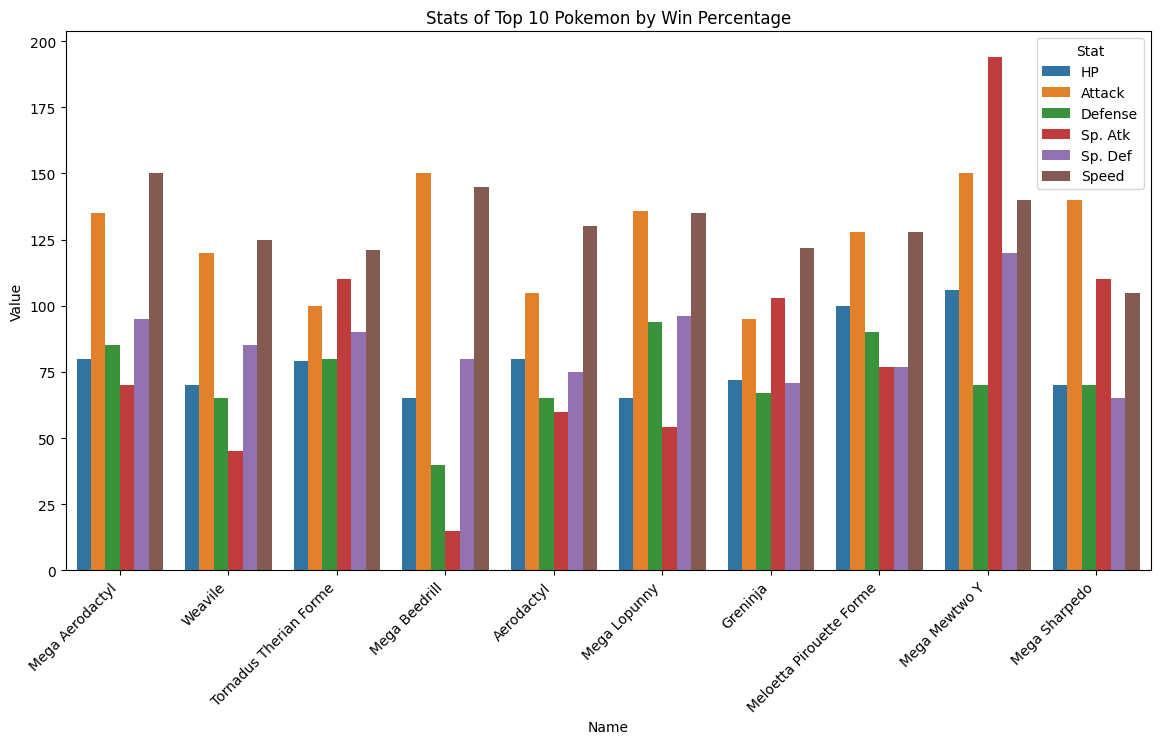

In [27]:
top_10_melted = top_10_stats.melt(
    id_vars="Name",
    var_name="Stat",
    value_name="Value"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=top_10_melted, x="Name", y="Value", hue="Stat")
plt.xticks(rotation=45, ha="right")
plt.title("Stats of Top 10 Pokemon by Win Percentage")
plt.show()

**Observation**: The top 10 Pokémon by win percentage all have win rates close to 1.0, meaning they won almost all of their recorded battles. The most obvious pattern among these Pokémon is their very high Speed. Every Pokémon in the top 10 has a Speed value above 100, and several have Speed values above 130, such as Mega Aerodactyl, Mega Beedrill, Aerodactyl, Mega Lopunny, and Mega Mewtwo Y.

The stat comparison also shows that many of the top 10 Pokémon have strong offensive stats, especially Attack or Sp. Atk. For example, Mega Beedrill and Mega Sharpedo have high Attack, while Mega Mewtwo Y has extremely high Sp. Atk. This suggests that fast offensive Pokémon tend to perform especially well in this dataset.

Defense does not appear to be the main shared characteristic among the top 10. Some Pokémon have moderate or low Defense but still have very high win percentages. This supports the earlier correlation analysis, where Defense had only a weak relationship with win percentage.

Overall, the top 10 analysis supports the conclusion that Speed is the most important visible factor associated with high win percentage, especially when combined with strong offensive stats.

In [28]:
# Prepare data for machine learning

# For a first version, use only numerical columns
features = [
    "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed",
    "Generation", "Legendary"
]

X = pokemon_merged[features]
y = pokemon_merged["Win_Percentage"]

In [29]:
# The Legendary column is Boolean, so we convert it to integer
X = X.copy()
X["Legendary"] = X["Legendary"].astype(int)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
# Model 1: Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_preds)

linear_mae

0.06368674750837296

In [32]:
# Model 2: Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)

rf_mae

0.05719663308238605

In [33]:
# Model 3: XGBoost

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)

xgb_mae

0.054924306696228976

In [34]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [linear_mae, rf_mae, xgb_mae]
})

results = results.sort_values("MAE")

results

,Model,MAE
2,XGBoost,0.054924
1,Random Forest,0.057197
0,Linear Regression,0.063687


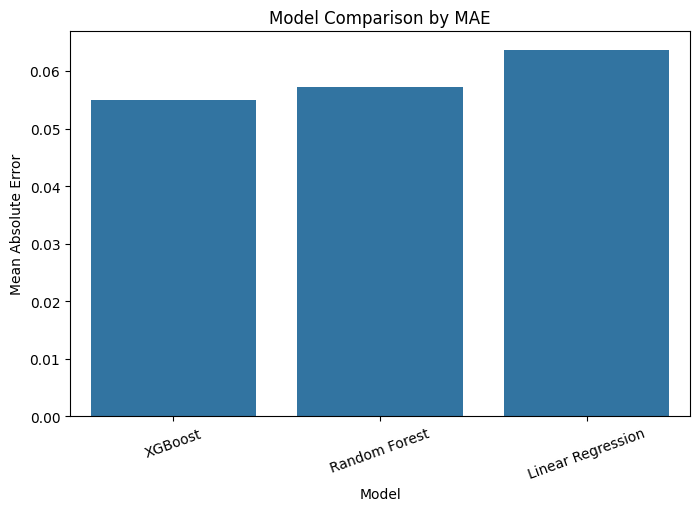

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="MAE")
plt.title("Model Comparison by MAE")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=20)
plt.show()

**Observation**: The three regression models were evaluated using Mean Absolute Error (MAE). Since the target variable, Win_Percentage, ranges from 0 to 1, the MAE can be interpreted as the average prediction error in win-rate units.

XGBoost achieved the lowest MAE, with a score of 0.0549. This means that, on average, its predictions were off by about 5.5 percentage points. Random Forest performed slightly worse, with an MAE of 0.0572, while Linear Regression had the highest MAE, 0.0637.

The tree-based models performed better than Linear Regression, which suggests that the relationship between Pokémon stats and win percentage is not purely linear. XGBoost was the best-performing model overall, although the difference between XGBoost and Random Forest was relatively small.

In [37]:
# Feature importance for Random Forest

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,Speed,0.884253
1,Attack,0.042316
4,Sp. Def,0.021929
3,Sp. Atk,0.016209
0,HP,0.015156
2,Defense,0.012332
6,Generation,0.007684
7,Legendary,0.000121


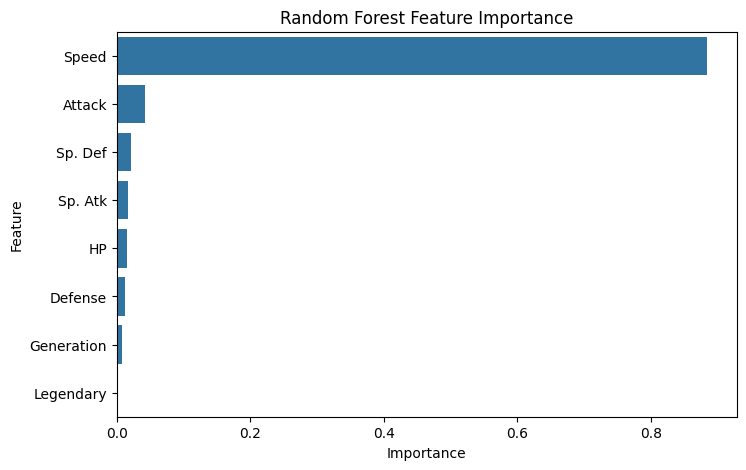

In [38]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

**Observation**: The Random Forest feature importance results show that Speed is by far the most important predictor of Win_Percentage. Speed accounts for approximately 88.4% of the total feature importance in the model. This strongly supports the earlier exploratory analysis, where Speed had the highest correlation with Win_Percentage and showed the clearest positive pattern in the pairplot.

Attack is the second most important feature, but its importance is much smaller, around 4.2%. The remaining variables, including HP, Defense, Sp. Atk, Sp. Def, Generation, and Legendary status, have relatively low importance values.

The very low importance of Legendary status suggests that the model does not rely much on whether a Pokémon is Legendary once the actual battle stats are included. In other words, the numerical stats, especially Speed, are more informative than the Legendary label itself.

Overall, the feature importance analysis confirms that Speed is the dominant factor used by the Random Forest model to predict win percentage.